## **Task 0 - Task Ordering:**

### Methodology
>The following is the task order that I decided on:
>
>>0) Task Ordering
>>1) Identifying the Prediction Target
>>2) Data Loading and Exploration
>>3) Data Splitting
>>4) Managing Missing Values
>>5) Encoding Categorical Variables
>>6) Feature Scaling
>>7) Feature Selection
>>8) Addressing Class Imbalance
>>9) Training a Logistic Regression Model

**Identifying the Prediction Target:**

**Data Loading and Exploration:** 

>*Before any model training or changes to the data are made, it is important to familiarize yourself with the data (How much data do we have?, What types of data?, Are the variables numerical or categorical?, What values are we missing?, etc.). At this early research stage, all information is allowed to be used as we are not yet in any danger of data leakage.*

**Data Splitting:**

**Managing Missing Values:**

**Encoding Categorical Variables:**

**Feature Scaling:**

**Feature Selection:**

**Adressing Class Imbalance:**

**Training a Logistic Regression Model:**

---

## **Task 1 - Identifying the Prediction Target:**

### Objective
>*Identify which column should be treated as the target variable.*

### Methodology
>The main goal of the assignment is the following:
>>*Given client and campaign information available at the time of contact, predict whether
>>the client subscribes to a term deposit (i.e., a type of short-term investment).*
>
>Given this, the best candidate for the prediction target is the column that best represents the result of the call.

### Findings
>The column most representative of the result of the call is "y". It indicates whether or not each customer did or did not subscribe to a term deposit. Duration and Campaign are columns that could superficially appear to be valid targets but they should not be treated as such. While duration may seem like a good indicator of the success of a call, it is not an outright indicator of the success of the call. Furthermore, duration is only known after the call, therefore it cannot be used as a metric to make predictions at the time that the customer is contacted. Campaign could also be mistaken as a valid target as one could falsely believe that multiple contacts with the customer is an indicator of success, however, it is does not outright indicate that a customer subscribed to a term deposit.

---

## **Task 2 - Data Loading and Exploration:**

### **Objective**
>*Familiarize yourself with the data. At this point, only observations are being made.*

### **Methodology**
>*To conduct the exploration of the dataset, I made use of Pandas, Seaborn, and Matplotlib. The dataset was loaded into a Pandas dataframe (df) and then various dataframe methods were employed to analyze the dataset. The visualizations were achieved with a combination of Seaborn and Matplotlib. While Seaborn was not necessary, it simplified the process of plotting histograms using columns of data directly from the dataframe.*

### **Implementation**

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load the Dataset:**

In [52]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


**Inspect the Dataset:**

In [53]:
print("Dataset shape:", df.shape)
df.info()
df.describe()

Dataset shape: (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.co

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Identify Numerical and Categorical Variables:**

In [54]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print(f"Numerical features:\n{list(numerical_features)}")

print(f"\nCategorical features:\n{list(categorical_features)}")

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


**Analysis of the Target Variable (y):**

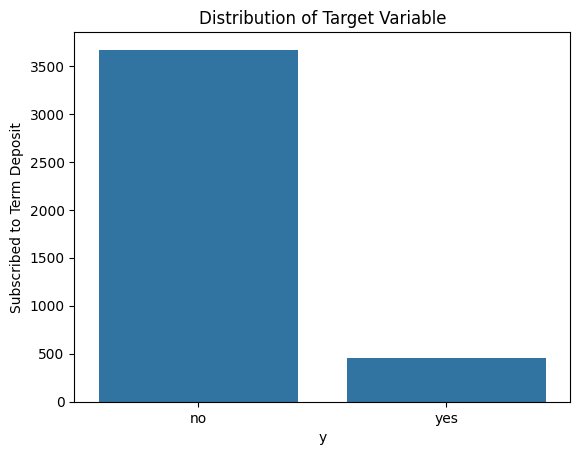

In [55]:
df['y'].value_counts()

sns.countplot(x='y', data=df)
plt.title("Distribution of Target Variable")
plt.ylabel('Subscribed to Term Deposit')
plt.show()

**Detection of Explicit Missing Values:**

In [56]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Detection of Implicit Missing Values:**

In [57]:
for col in categorical_features:
    print(col, df[col].value_counts().get("unknown",0))

job 39
marital 11
education 167
default 803
housing 105
loan 105
contact 0
month 0
day_of_week 0
poutcome 0
y 0


**Visualization of Two Numerical Variables (age / campaign):**

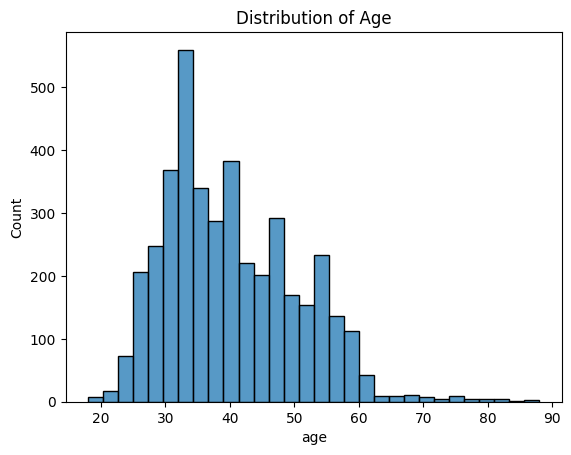

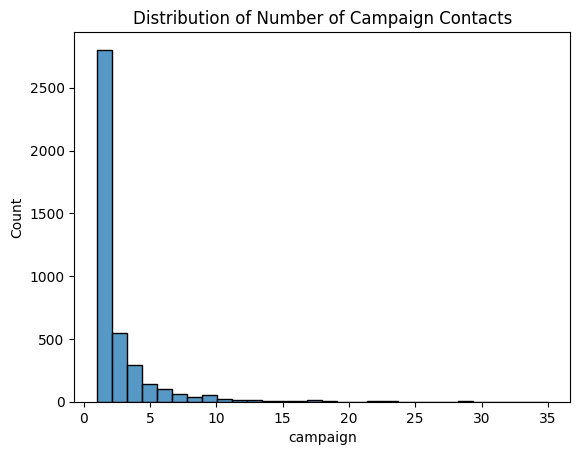

In [58]:
sns.histplot(df['age'], bins=30)
plt.title("Distribution of Age")
plt.show()

sns.histplot(df['campaign'], bins=30)
plt.title("Distribution of Number of Campaign Contacts")
plt.show()

**Visualization of Two Categorical Variables (job / marital):**

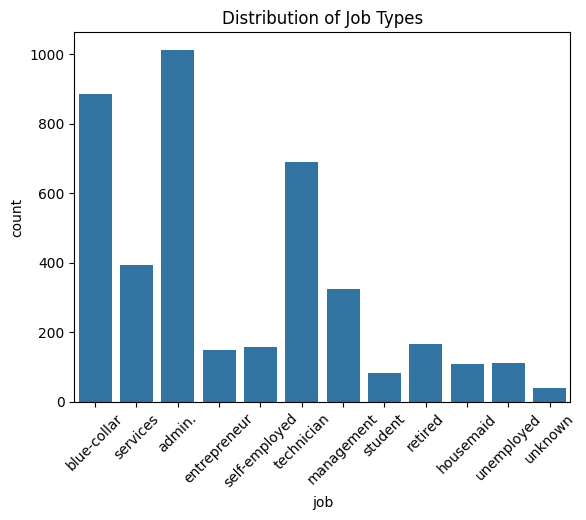

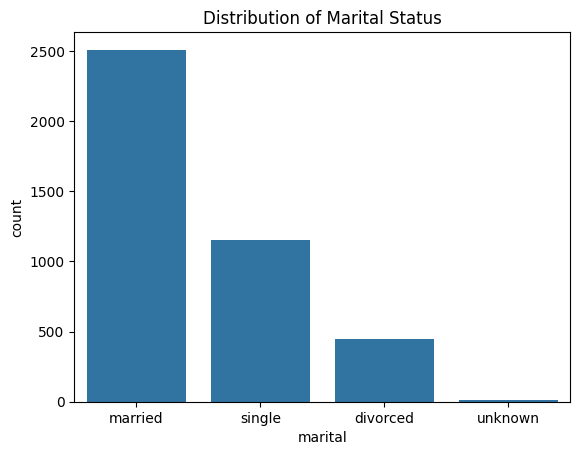

In [59]:
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Job Types")
plt.show()

sns.countplot(x='marital', data=df)
plt.title("Distribution of Marital Status")
plt.show()

### Findings
>*The dataset contains 4,119 observations and 21 variables*
>
>*The numerical features of the dataset are:*
>>'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
>
>*The categorical features of the dataset are:*
>>'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y'
>
>*The distribution of the target variable reveals a significant class imbalance, being heavily biased toward no.*
>
>*While no explicit missing values were found, the following implicit missing values categorized as "unknown" were found:*
>>job 39\
>>marital 11\
>>education 167\
>>default 803\
>>housing 105\
>>loan 105\
>>contact 0\
>>month 0\
>>day_of_week 0\
>>poutcome 0\
>>y 0
>
>*The two numerical variables that were visualized are 'age' and 'campaign'. Age is somewhat normally distributed about ~35, and campaign is highly skewed toward lower values. This suggests that 'campaign' may contain outliers or extreme values.*
>
>*The two categorical variables that were visualized are 'job' and 'marital'. The most common job is admin, followed closely by blue-collar and technician. The majority of customers are married beating out single customers by roughly ~50% and divorced customers by a much more significant margin.*
>
>*One variable that may require special consideration due to availability at prediction time is 'duration'. Because duration is only available after the call has ended, it is a metric that is unavailable at prediction time.*

---

## **Task 3 - Data Splitting:**

### **Objective**
>*Split the dataset into training, validation, and test sets while ensuring equitable class distribution.*

### **Methodology**
>*To properly split the dataset, I first made sure to drop the target variable from the dataframe before splitting to avoid data leakage. I then used "train_test_split" from the scikit-learn library to split the new dataframe and target varible into training and temporary sets because the function is only capable of splitting data into two parts at once. I then split the temporary set into the validation and test sets. I used the stratify argument throughout to ensure equitable class distribution between the sets.*

### **Implementation**

In [60]:
from sklearn.model_selection import train_test_split

**Separate the Target Variable from the Dataframe:**

In [63]:
x = df.drop('y', axis=1)
y = df['y']

**Split the Dataset into a Training Set and a Temporary Set:**

In [64]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

**Split the Temporary Set into a Validation Set and a Test Set:**

In [65]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

**Check that the Split was Successful:**

In [67]:
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (2883, 20) (2883,)
Validation set: (618, 20) (618,)
Test set: (618, 20) (618,)


**Check Class Distribution Across Splits:**\
(Stratified Splitting)

In [68]:
print("Full dataset:\n", y.value_counts(normalize=True))
print("\nTraining set:\n", y_train.value_counts(normalize=True))
print("\nValidation set:\n", y_val.value_counts(normalize=True))
print("\nTest set:\n", y_test.value_counts(normalize=True))

Full dataset:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Training set:
 y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation set:
 y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Test set:
 y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


### Findings
>*To split the dataset into training, validation, and test sets I used a 70-15-15 split respectively. I chose to allocate the majority of the data to the training set to allow the model to recognize significant patterns, while leaving enough data in the other two sets to allow for reliable performance estimates*
>
>*Stratified splitting was necessary in this case due to the aforementioned class imbalance in the target variable. It was imperative that all three sets reflected this bias toward the "no" class so that any performance estimates against the validation or test sets reflected a realistic class distribution*
>
>*Splitting must occur at the very beginning of the training process, before any feature engineering or modifications take place. This is due to the risk of data leakage. Say for example, we chose to conduct standardization before splitting. The paramaters such as mean and standard deviation that would be learned from the complete dataset, would reflect values that would later be included in the validation and test sets. This means that by transforming the training set with these "corrupted" parameters, we are inadvertently training the model on patterns that are reflected in the validation and test sets. This leads to overfitting and overly optimistic results for a model that generalizes poorly.*
>
>*The same could be said for something like resampling. Say for example a dataset has a class imbalance, much like ours, and we choose to resample before splitting. Although the training set may not suffer too greatly, our model will not generalize well because it was tested against data that is no longer representative of the true distribution.*

---